# MAIT 24 小时降水自适应集成程序说明

本笔记与 `docs/MAIT_24H_程序说明.md` 保持一致，概括 **MAIT 24h** 的应用场景、程序架构、完整算法流程、配置与运行方式。

**核心路径**：`src/mait_24h_cli.py`（主入口与命令行）、`src/mait_24_plugin.py`（TS 权重/插值）、`src/mait_24_plugin_util.py`（读数）、`utils/mai_24_plugin_context.py`（RunContext）、`utils/util_new.py`（配置与 I/O）。命令行：`python -m cli` 或 `python src/mait_24h_cli.py`。


## 1. 文档与工程定位

- **程序性质**：多模式 **24 小时累积降水** 的业务型集成流水线；在站点维度估计动态权重并完成融合与订正，再插值到规则经纬网格，输出 Micaps 等业务格式。
- **设计目标**：与既有业务数据接口（Micaps3/Micaps4 等）对齐；支持按预报时效与空间分区调整权重；支持掩码约束下的格点产品写出。
- **相关材料**：详细说明见 `docs/MAIT_24H_程序说明.md`；历史简要说明见项目根目录 `README.md`。


## 2. 应用场景

| 场景 | 说明 |
|------|------|
| **业务模式集成** | 对多个数值模式 24h 降水预报进行融合，得到单套「集成+订正」后的站点与网格产品。 |
| **时效序列批处理** | 对多个起报时次、多个预报时效（如 36–252 h、步长 24 h）循环处理，适用于业务化日/旬滚动。 |
| **分区权重** | 通过 `split_lat`、`split_lon` 将区域划分为若干子块，每块独立做评分与权重，缓解大范围单一权重带来的空间失配。 |
| **权重记忆（beta）** | 读入历史评分、写出本轮 `score_last`，实现跨时次滚动更新（路径由 `beta_path` 配置）。 |
| **有效范围约束** | 使用与目标网格一致的掩码（默认 `resource/mask010.nc`，由 `mait_24.ini` 的 `mask_nc` 指定），避免在服务区域外产生无业务含义的格点值。 |

**不适用或需自行扩展的情形**：模式动力过程改进、观测新型质控、与本仓库 Micaps 接口不同的全新数据格式等，不在本程序默认范围内。


## 3. 程序架构与模块划分

### 3.1 处理阶段划分

程序按时间尺度分为三个阶段：**配置准备**（每个 `time_input` 一次）、**时效循环**（每个 `predict_valid` 一次）、**产品写出**（嵌入时效循环末尾）。

```mermaid
flowchart TB
    subgraph P0["阶段 0：任务派发"]
        A[process] --> B{is_multi}
        B -->|否| C[顺序调用 process_single]
        B -->|是| D[SimpleParallelTool 多进程]
        C --> E[RunProcess._process_single]
        D --> E
    end
    subgraph P1["阶段 1：配置准备 _setup_context"]
        E --> F[get_resolved_paths]
        F --> G[_prepare / _analysis_para_ini / _analysis_background_ini]
        G --> H[build_run_context → RunContext]
    end
    subgraph P2["阶段 2：时效循环"]
        H --> I[read_grid_mask_nc]
        I --> J{predict_valid ∈ list}
        J --> K[读历史与当前资料]
        K --> L[数据可用性判定]
        L --> M[beta 读写]
        M --> N[AnalysisTsWeightProcess]
        N --> O[写 Micaps3 / beta]
        O --> P[StationDataInterp2GridDataProcess]
        P --> Q[write_grid_to_micaps4]
        Q --> J
    end
```

### 3.2 运行上下文（RunContext）

`RunContext`（`utils/mai_24_plugin_context.py`）在配置准备阶段组装，贯穿时效循环向下游传递。`build_run_context` **不执行文件读取**，仅将已解析参数装箱为四层结构：

| 层级 | 字段 | 含义 |
|------|------|------|
| `ctx.paths` | `beta_path_template`, `fact_path`, `output_sample_path`, `model_path`, `background_templates` | 路径模板 |
| `ctx.models` | `model_name` | 模式键名序列，与 `para_24.ini` 一致 |
| `ctx.grid` | `clip_coords`, `split_lat`, `split_lon`, `area_scale`, `predict_type` | 空间分区与算法标量 |
| `ctx.session` | `dt_now`, `sd_sta_info`, `is_obs_bjt` | 起报时刻、站点表、实况时区标志 |

### 3.3 日志与异常

- 日志在 `RunProcess._setup_context` / `_process_single` 中通过 `init_run_log` 创建，仅主流程写入。
- 子模块不记录日志；读数失败等情况抛出异常，由主流程捕获并写入 `log.error`。
- 多进程运行时，子进程日志文件在 `time_input` 后缀基础上附加进程号，避免并发写入同一文件。

### 3.4 目录与核心文件

| 路径 | 作用 |
|------|------|
| `src/mait_24h_cli.py` | 主入口、Clize 命令行（`process` / `main`） |
| `src/mait_24_plugin.py` | `AnalysisTsWeightProcess`、`StationDataInterp2GridDataProcess` |
| `src/mait_24_plugin_util.py` | 模式与实况读取、背景 ini 解析 |
| `utils/mai_24_plugin_context.py` | `RunContext` 与 `build_run_context` |
| `utils/base_plugin.py` | 后处理插件基类 `PostProcessingPlugin` |
| `utils/multipro_plugin.py` | `SimpleParallelTool` 多进程封装 |
| `utils/util_new.py` | INI 解析、掩码、Micaps 写出、beta、格点/站点工具 |
| `utils/util_env.py` | 全局路径与运行默认值（`resource/mait_24.ini`） |
| `cli/` | `python -m cli` 转调 `src/mait_24h_cli.py` |

运行期约定：`src` 为工作目录（程序内 `os.chdir`），并需能将 `utils` 作为包导入；CLI 会自动将项目根目录与 `src` 加入 `sys.path`。


## 4. 完整算法流程与关键节点实现

### 4.1 阶段 0：任务派发

| 项目 | 说明 |
|------|------|
| **入口** | `mait_24h_cli.process` |
| **输入** | `time_inputs` 及运行参数；缺省项由 `utils/util_env.get_default_*` 从 `resource/mait_24.ini` 补齐 |
| **原理** | 每个起报时刻对应一个 `RunProcess` 实例；`is_multi=True` 时由 `SimpleParallelTool` 并行执行 |
| **实现** | `src/mait_24h_cli.py`；`utils/multipro_plugin.py` |

### 4.2 阶段 1：配置准备（`_setup_context`）

| 步骤 | 实现 |
|------|------|
| 工作目录切换至 `src` | `os.chdir` |
| 路径解析 | `utils/util_env.get_resolved_paths` |
| 站点表 | `utils/util_new._prepare` |
| 模式配置 | `utils/util_new._analysis_para_ini` |
| 背景模板 | `mait_24_plugin_util._analysis_background_ini` |
| 上下文装箱 | `utils/mai_24_plugin_context.build_run_context` |

### 4.3 阶段 2-A：资料读取

**时间换算**（`src/mait_24_plugin_util.py`）：

- `_analysis_time1`：`hour > 12 且 ≤ 23` → 当日 00 UTC（`num3=0`）；否则 → 前一日 12 UTC（`num3=12`）
- `_analysis_time2`：计算实况 `dt_fact`、验证 `dt_valid`；`is_obs_bjt=True` 时加 8 h
- `_analysis_time3`：在 `dt_fact` 基础上减 `predict_valid`，得历史模式起报 `dt_model_before`

**读数**：`_read_history_source_micaps3`（实况 + 昨日同时效模式）；`_read_now_source_micaps3_micaps4`（当前模式 Micaps3 + 背景 Micaps4 + `grid_base`）。

**可用性判定**（`src/mait_24h_cli.py`）：`np.any(sta_before_flg)` 与 `np.any(sta_current_flg)`，否则终止当前时效。

### 4.4 阶段 2-B：beta 评分记忆

按子区 `(i,j)` 生成 `%02d_%02d_TTT.npy` 路径；向前检索至多 9 天读取 `score_before`；TS 计算后写出 `score_last`。实现：`utils/util_new.py`。

### 4.5 阶段 2-C：分区 TS 权重与站点集成

核心：`AnalysisTsWeightProcess._analysis_ts_weight`（`src/mait_24_plugin.py`）

1. 按 `split_lon/lat` 划分子区；训练区向外扩展 `area_scale=0.5` 倍格距
2. 对阈值 **0.1/10/25/50 mm** 计算 `ts_fact`（模式 vs 实况）与 `ts_each`（模式间）
3. `score_tmp = ts_fact / (e_ts + 100000)`，按量级权重累加得 `score_now`
4. `score_last = 0.9·score_before + 0.1·score_now`（`α=0.1`）
5. 时效筛选：108–238 h 仅保留 `ecModel`；其它保留前 5 个模式
6. 线性集成 + `MetevaFrequencyMatch` 频率匹配（20 级，0.01–250 mm）

### 4.6–4.8 产品写出

| 阶段 | 内容 | 实现 |
|------|------|------|
| 2-D | 子区合并、beta 更新、Micaps3 站点 | `_process_single` / `write_beta_npy` / `_data_write_to_micaps3` |
| 2-E | 掩码外圈约束 + Cressman（8/6/4/2 倍格距）+ 平滑 + 网格频率匹配（19 级） | `StationDataInterp2GridDataProcess` |
| 2-F | Micaps4 / NetCDF 写出，`clip_coords` 裁剪 | `write_grid_to_micaps4` |

长时效（≥108 h）格点全场 ×0.8，≥240 mm 封顶 250 mm；小于 0.01 mm 置零。


## 5. 代码索引

| 内容 | 位置 |
|------|------|
| 主循环 | `src/mait_24h_cli.py` → `_setup_context` / `_process_single` |
| 运行上下文 | `utils/mai_24_plugin_context.py` → `build_run_context` |
| 时间换算 | `src/mait_24_plugin_util.py` → `_analysis_time1/2/3` |
| TS 权重与站点频率匹配 | `src/mait_24_plugin.py` → `AnalysisTsWeightProcess` |
| Cressman 与网格频率匹配 | `src/mait_24_plugin.py` → `StationDataInterp2GridDataProcess` |
| INI/beta/Micaps/掩码/日志 | `utils/util_new.py` |
| 全局默认路径 | `utils/util_env.py` |
| 多进程 | `utils/multipro_plugin.py` |


## 6. 配置文件说明

### 6.1 `para_24.ini`（GBK，固定行序）

1. `modelNum=<N>`
2. N 行 `模式键名=<Micaps3 路径模板>`
3. `fact=<实况路径模板>`
4. `staoutputPath=<输出路径模板>`

占位符：`YYYYMMDD`、`YYYYMMDDHH`、`YYMMDDHH`、`VVV`/`TTT` 等，由 meteva 风格路径函数展开。

### 6.2 `para_24_background.ini`

各模式 **MICAPS4** 路径，GBK，每行 `模式键名=路径模板`；经 `build_run_context` 进入 `ctx.paths.background_templates`。默认路径由 `resource/mait_24.ini` 的 `background_ini` 指定。

### 6.3 `resource/mait_24.ini`

全局默认：`para_ini`、`background_ini`、`bate_file`、`station_info`、`mask_nc`、`clip_coords`、`predict_valid_list` 等。


## 7. 运行参数说明

### 7.1 `mait_24h_cli.process`

| 参数 | 类型 | 含义 | 默认/备注 |
|------|------|------|-----------|
| `time_inputs` | `list[str]` | 起报时刻列表 | 必传 |
| `predict_valid_list` | `list[int]` | 预报时效（小时） | 默认 36..252 步长 24 |
| `para_path` | `str \| None` | `para_24.ini` 路径 | `None` → `resource/mait_24.ini` 的 `para_ini` |
| `beta_path` | `str \| None` | beta 目录模板 | `None` → `mait_24.ini` 的 `bate_file` |
| `is_obs_bjt` | `bool` | 实况是否为北京时间 | 默认 `True` |
| `is_multi` | `bool` | 多进程 | 默认 `False` |
| `clip_coords` | `list \| None` | `[slon, elon, slat, elat, dlon, dlat]` | `None` |
| `pro_count` | `int` | worker 数 | 默认 `4` |
| `split_lat` / `split_lon` | `int` | 分区数 | 默认 `1` |

### 7.2 运行期固定约定

| 项 | 值 |
|----|-----|
| `predict_type` | 24 |
| `area_scale` | 0.5 |
| 掩码 | `resource/mask010.nc` |
| 日志 | `log/YYYYMMDD_{time_input}[_pid].txt` |

### 7.3 Python 调用示例

批处理脚本见 `test/test_mait_24h.py`。

### 7.4 命令行（Clize）

在项目根目录执行：

```text
python -m cli --time-inputs=202507010800,202507012000 --predict-valid-list=36,60,84,108,132,156,180,204,228,252 --is-obs-bjt=True --is-multi --clip-coords=70.0,140.0,0.0,60.0,0.1,0.1 --pro-count=8 --split-lat=2 --split-lon=2
```

等价命令：`python src/mait_24h_cli.py ...`（参数相同）。

完整参数表见 `docs/MAIT_24H_程序说明.md` 第 7.4 节。


## 8. 依赖环境

- **Python 3.x**
- **numpy**、**pandas**
- **meteva_base**；主流程及检验脚本还需 **meteva**
- **xarray**（`utils/util_new.py`）
- 掩码工具：`geopandas`、`shapely`（`utils/util_mask_file.py`）
- 命令行：**clize**（≥5，`requirements-cli.txt`）

## 9. 单元测试

```text
python -m pytest test/ -v
```

| 文件 | 覆盖 |
|------|------|
| `test/test_run_context.py` | `build_run_context`、ini 解析、`util_env` |
| `test/test_mait_24h_cli_flow.py` | `_setup_context`、多进程日志分文件 |
| `test/test_mait_24h.py` | 批处理脚本（需完整数据环境） |

## 10. 输出产品

- **站点集成**：Micaps3（`_data_write_to_micaps3`）
- **网格产品**：Micaps4（`write_grid_to_micaps4`），受掩码与 `clip_coords` 影响
- **beta**：分区 npy 评分文件，供 `read_his_beta_npy` 使用


In [ ]:
# Notebook 中驱动主程序前设置路径
from pathlib import Path
import sys

_REPO = Path('..').resolve()  # notebook 位于 nbs/ 下
for _p in (_REPO / 'src', _REPO):
    s = str(_p)
    if s not in sys.path:
        sys.path.insert(0, s)

# import mait_24h_cli
# mait_24h_cli.process(time_inputs=['202507010800'], is_multi=False)


---

## 11. 检验分析

`src/mait_24_verify.py` 中的 **`get_ts(sta_all, grade_list, product_list, h5_file)`** 调用 Meteva 的 `mpd.score`，对给定 `sta_all` 按预报时效 `dtime`、各产品 `grade_list` 计算 **TS**，结果写入 HDF5（key=`ts`），便于出图对比。

**前提**：`sta_all` 需与 `prepare_dataset` 输出一致（含观测列 `ob`、时效 `dtime` 及 `product_list` 中各产品预报列）。

数据准备插件位于 `utils/data_prepare_plugin.py`：`from utils.data_prepare_plugin import prepare_dataset`。


         level                time  dtime     id     lon    lat        ob  \
0            0 2025-07-01 08:00:00     36  45004  114.17  22.31       0.0   
1            0 2025-07-01 08:00:00     36  45005  114.17  22.30       0.0   
2            0 2025-07-01 08:00:00     36  45007  113.92  22.31  999999.0   
3            0 2025-07-01 08:00:00     36  45011  113.57  22.16       6.8   
4            0 2025-07-01 08:00:00     36  45013  113.57  22.16  999999.0   
...        ...                 ...    ...    ...     ...    ...       ...   
1441656      0 2025-07-31 20:00:00    252  59991  112.89   9.54  999999.0   
1441657      0 2025-07-31 20:00:00    252  59993  114.22  10.21  999999.0   
1441658      0 2025-07-31 20:00:00    252  59994  114.29   9.71  999999.0   
1441659      0 2025-07-31 20:00:00    252  59996  114.50   9.91  999999.0   
1441660      0 2025-07-31 20:00:00    252  59997  114.37  10.38  999999.0   

         ec_dz          ec  aifs_dz    aifs  fengqing_dz   fengqing  mait  

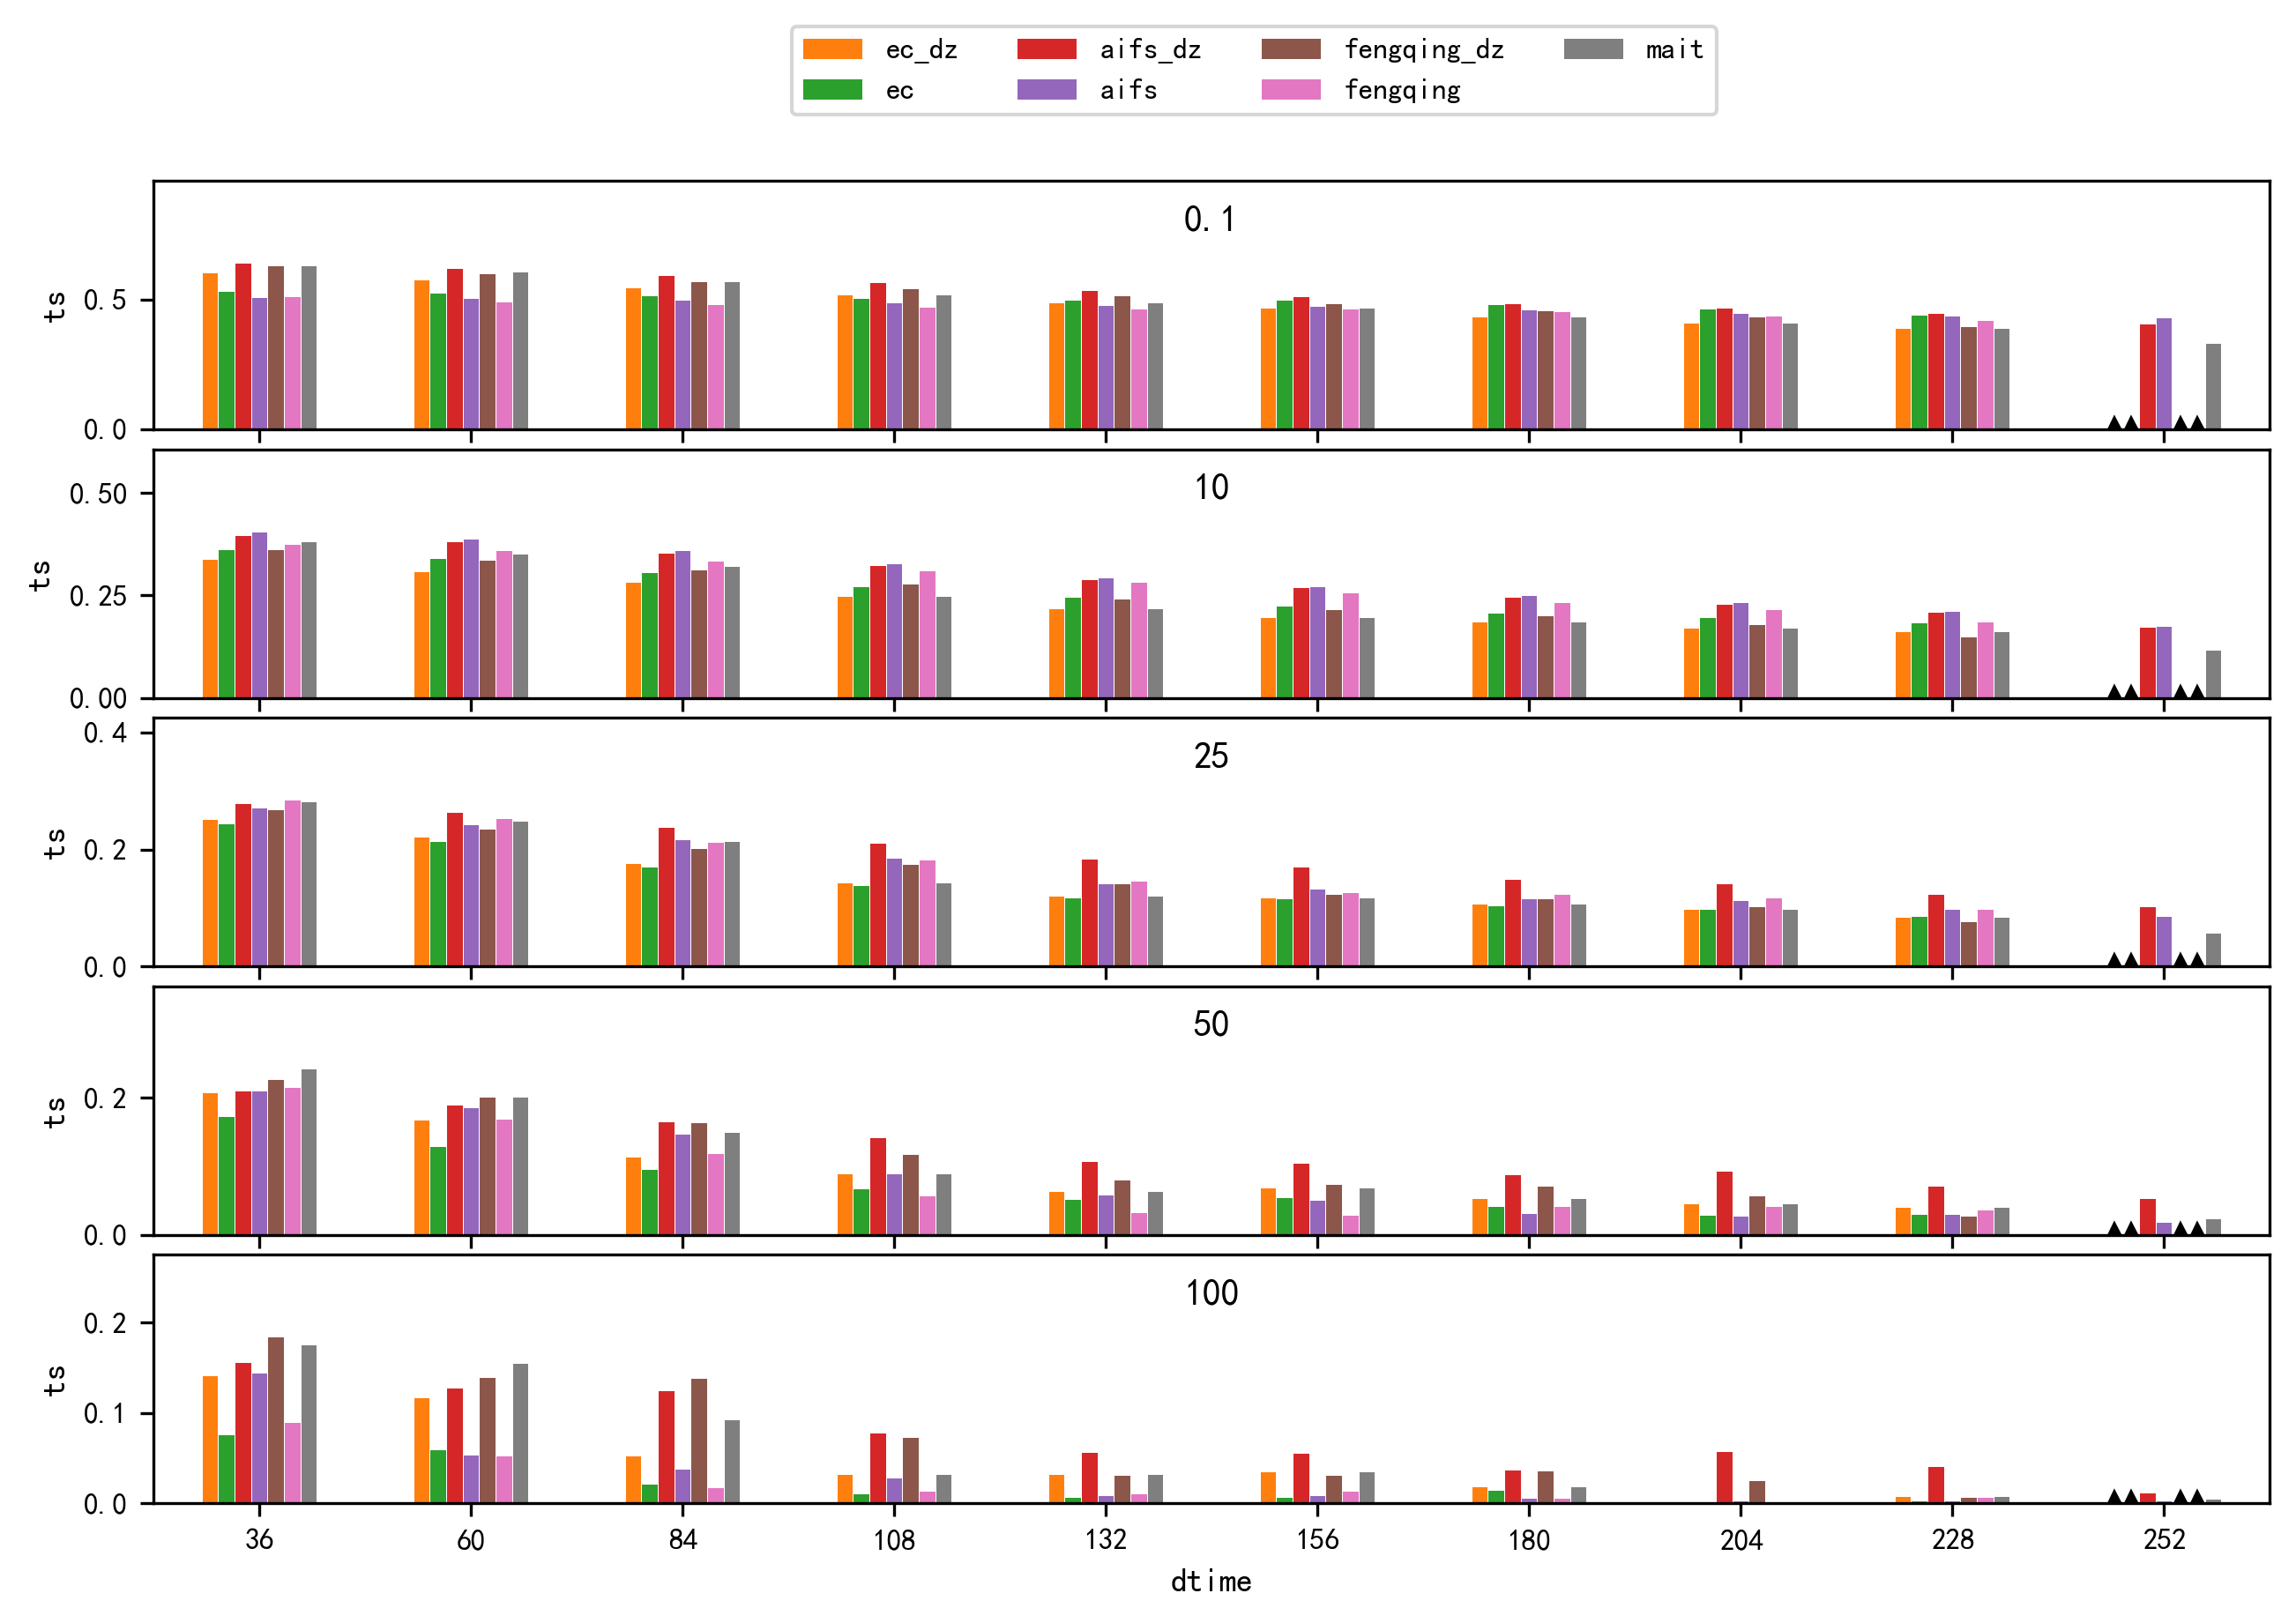

     时效         产品名称            0.1             10             25  \
0    36        ec_dz       0.602561       0.336252       0.250648   
1    36           ec       0.529277       0.360945       0.243348   
2    36      aifs_dz       0.637759       0.395488       0.277774   
3    36         aifs       0.507563       0.404316       0.270796   
4    36  fengqing_dz       0.628316       0.360332       0.267322   
..  ...          ...            ...            ...            ...   
65  252      aifs_dz       0.402638       0.172069       0.101919   
66  252         aifs       0.426862       0.172679       0.084346   
67  252  fengqing_dz  999999.000000  999999.000000  999999.000000   
68  252     fengqing  999999.000000  999999.000000  999999.000000   
69  252         mait       0.329612       0.115829       0.055771   

               50            100  
0        0.206725       0.140407  
1        0.171259       0.075342  
2        0.208821       0.155184  
3        0.209075       0.14408

,时效,产品名称,0.1,10,25,50,100
0,36,ec_dz,0.602561,0.336252,0.250648,0.206725,0.140407
1,36,ec,0.529277,0.360945,0.243348,0.171259,0.075342
2,36,aifs_dz,0.637759,0.395488,0.277774,0.208821,0.155184
3,36,aifs,0.507563,0.404316,0.270796,0.209075,0.144082
4,36,fengqing_dz,0.628316,0.360332,0.267322,0.225866,0.183603
...,...,...,...,...,...,...,...
65,252,aifs_dz,0.402638,0.172069,0.101919,0.052862,0.011068
66,252,aifs,0.426862,0.172679,0.084346,0.018088,0.002217
67,252,fengqing_dz,999999.000000,999999.000000,999999.000000,999999.000000,999999.000000
68,252,fengqing,999999.000000,999999.000000,999999.000000,999999.000000,999999.000000


In [2]:
from pathlib import Path
import sys

REPO = Path('..').resolve()
SRC = REPO / 'src'
for p in (SRC, REPO):
    s = str(p)
    if s not in sys.path:
        sys.path.insert(0, s)

from mait_24_verify import get_ts, para_example
from utils.data_prepare_plugin import prepare_dataset

import pandas as pd

h5_file = r'D:\data1\zhongzhuan\20260722\mait_sta_all_202507.h5'
sta_all = pd.read_hdf(h5_file, key='sta_all')
sta_all.rename(columns={
    'ecModel': 'ec_dz',
    'globalECMWF_C1D': 'ec',
    'aifs': 'aifs_dz',
    'globalECMWF_AIFS': 'aifs',
    'fengqing': 'fengqing_dz',
    'FENGQING': 'fengqing',
}, inplace=True)

sta_all = sta_all.loc[:, ~sta_all.columns.isin(['mait_ai', 'mait_chen'])]
print(sta_all)

product_list = ['ec_dz', 'ec', 'aifs_dz', 'aifs', 'fengqing_dz', 'fengqing', 'mait']
grade_list = [0.1, 10, 25, 50, 100]
get_ts(sta_all, grade_list, product_list, h5_file)


## 12. 版本结果对比

将 **NIMM 标准业务版本**（`mait_real_time` 输出）与本仓库版本（`resource/data/output`）在同一起报时刻与预报时效下的格点/站点产品进行可视化对比。


m4 文件时间格式错误，因此数据时间被强制设置为2099年1月1日08时，建议在读取时设置参数time
m4 文件时间格式错误，因此数据时间被强制设置为2099年1月1日08时，建议在读取时设置参数time


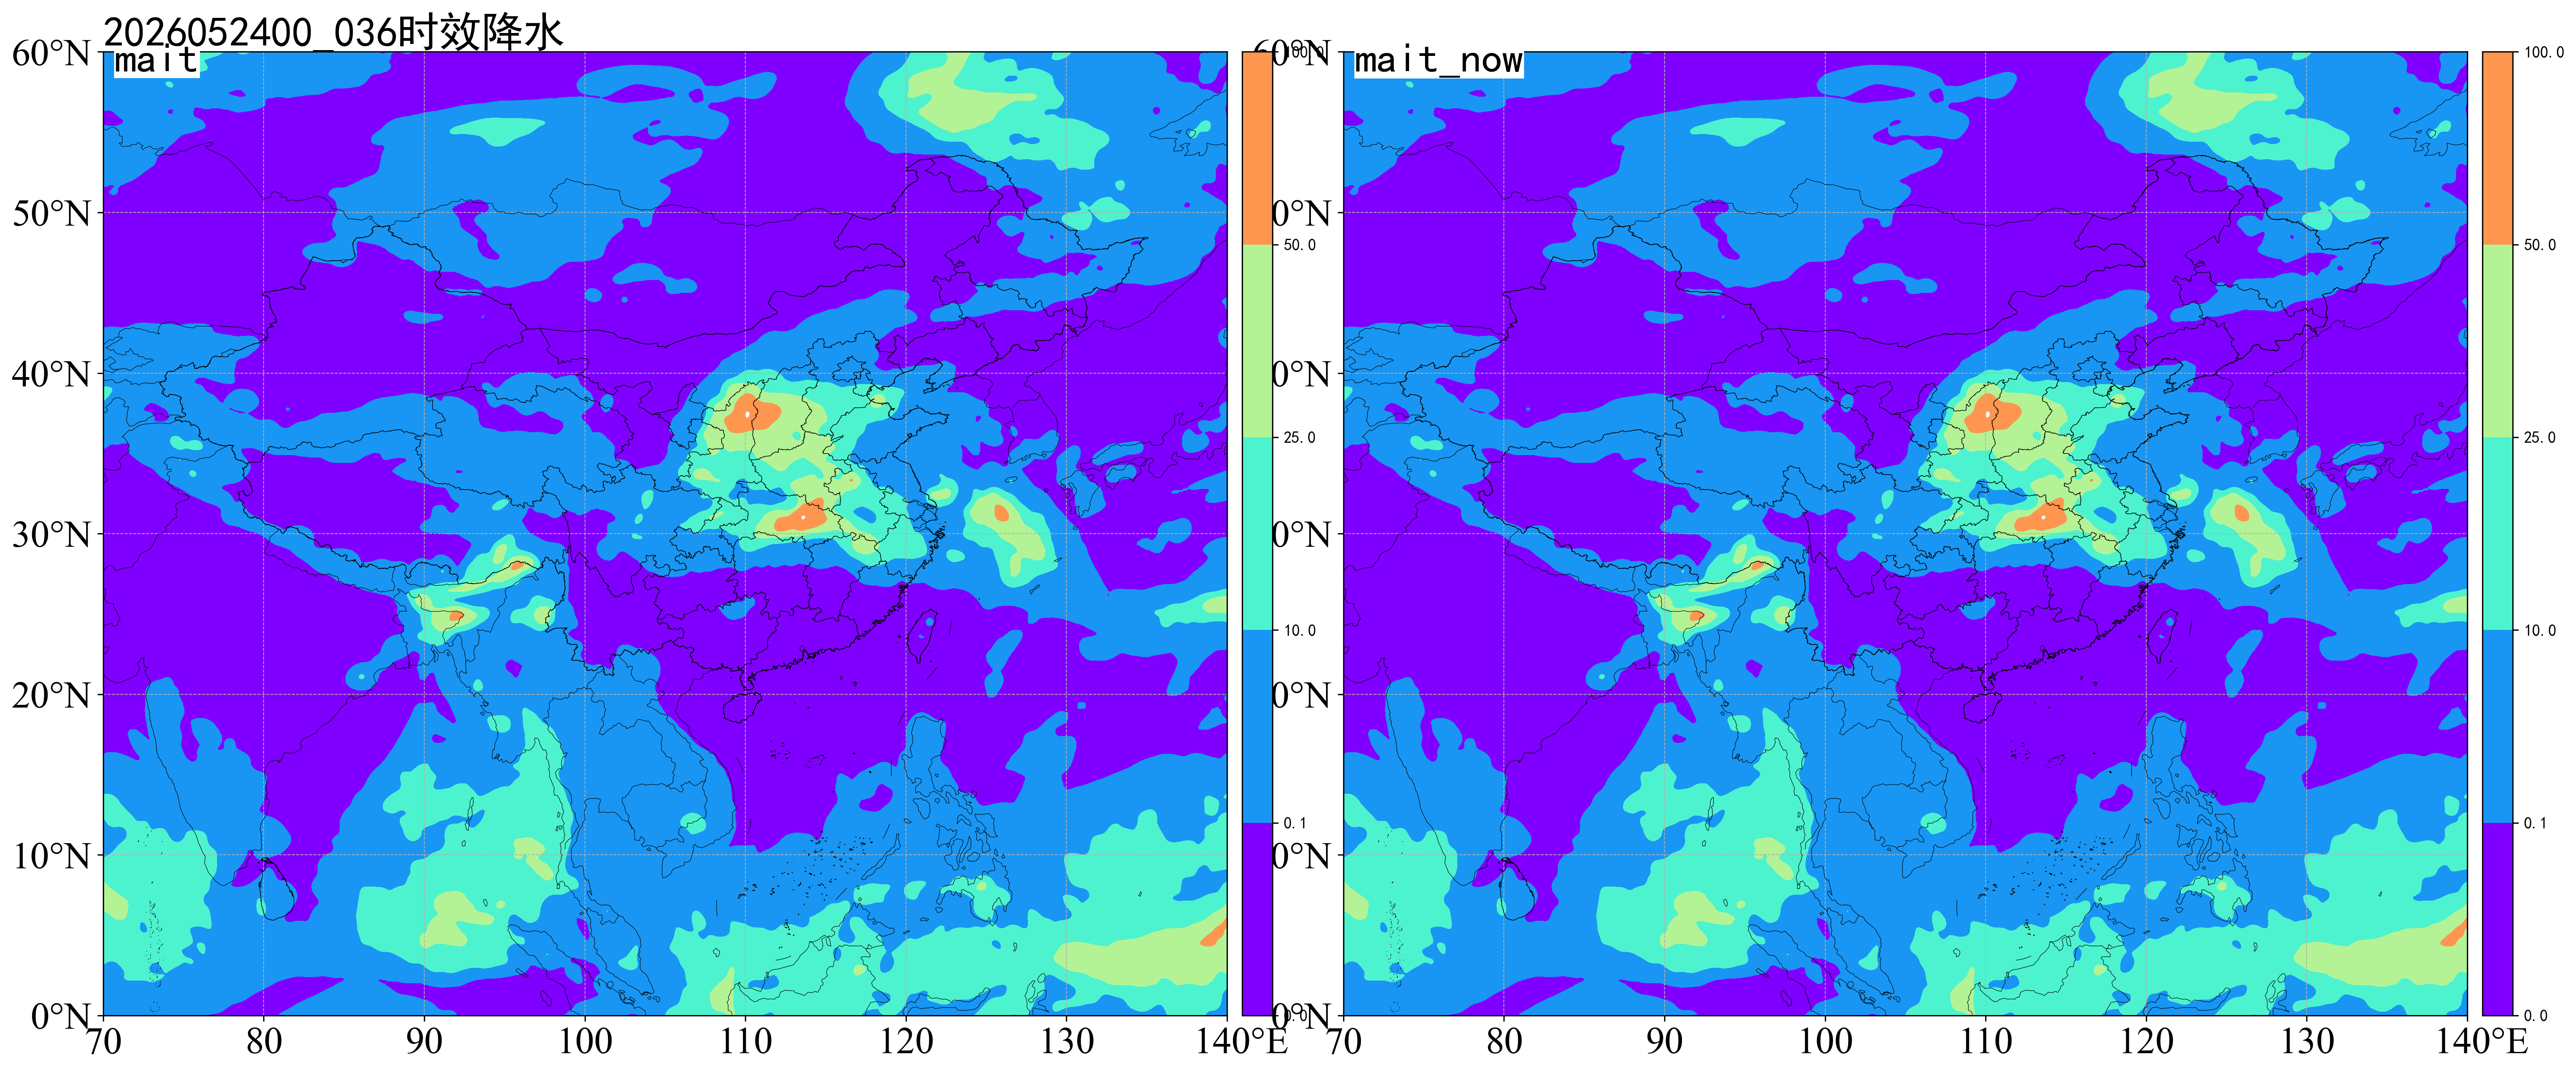

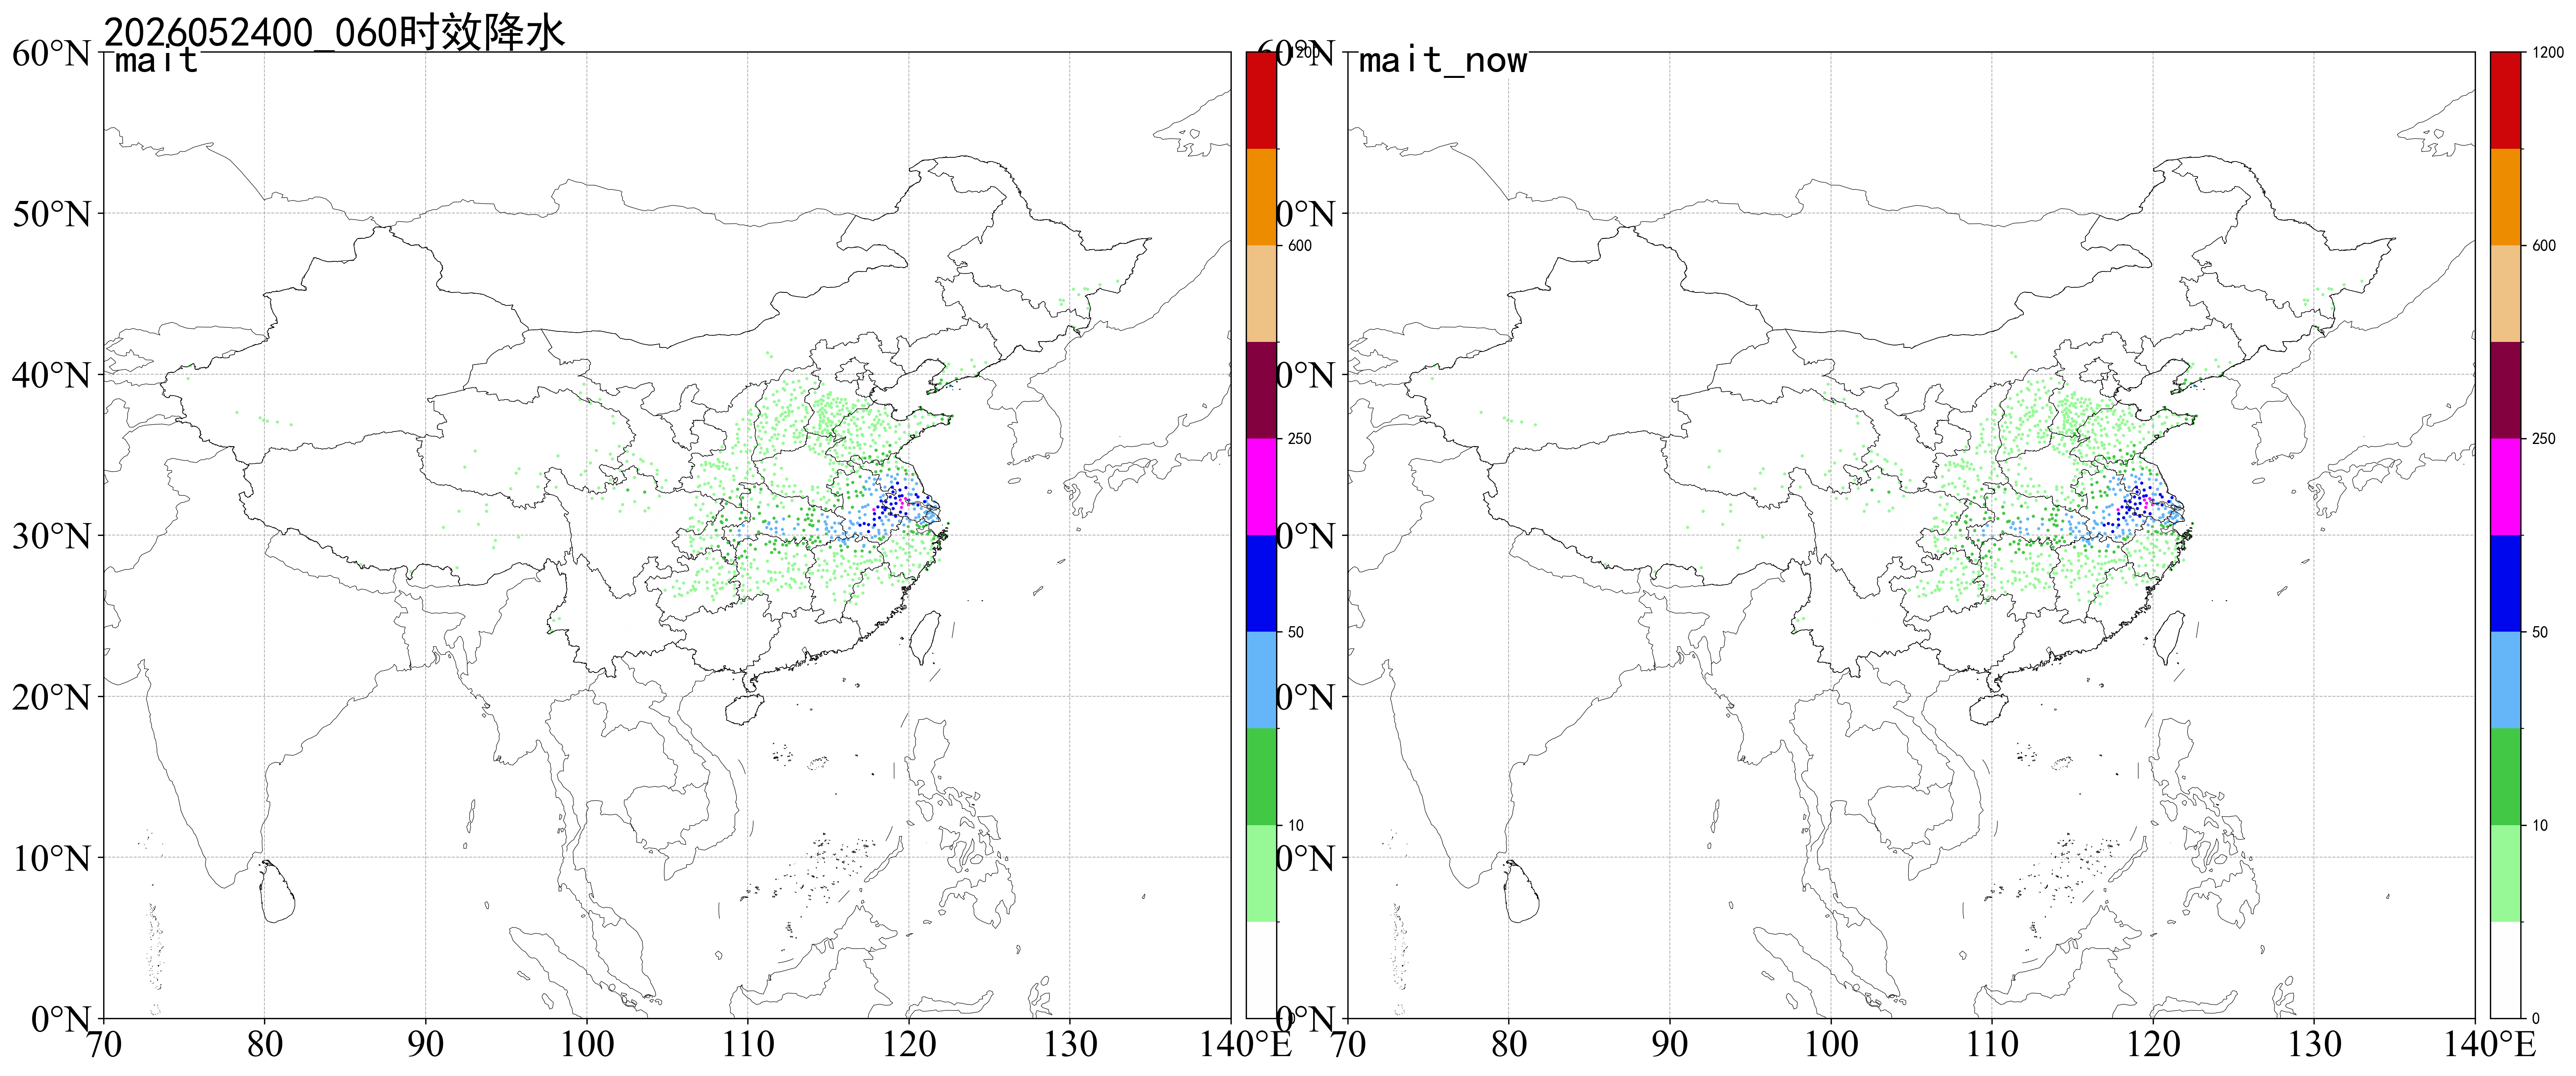

In [3]:
import meteva_base as meb
import numpy as np
import matplotlib.pyplot as plt
import datetime

mait = r'D:/Work/mait_real_time/output_mait_24/YYYYMMDD/YYYYMMDDHH.TTT.m4'
mait_now = r'D:/Work/mait_24h/resource/data/output/YYYYMMDD/YYYYMMDDHH.TTT.m4'
png_dir = r'D:/Work/mait_24h/resource/data/pngs/YYYYMMDD'
dtime = 36
ftime = '2026052400'

fo_time = datetime.datetime.strptime(ftime, '%Y%m%d%H')
mt_2_path = meb.get_path(mait, fo_time, dtime)
mt_1_path = meb.get_path(mait_now, fo_time, dtime)
pg_path = meb.get_path(png_dir, fo_time)

mt1_grd = meb.read_griddata_from_micaps4(mt_2_path)
mt2_grd = meb.read_griddata_from_micaps4(mt_1_path)

map_extend = [70.0, 140.0, 0, 60.0]
axs = meb.creat_axs(2, map_extend, ncol=2, add_index=['mait', 'mait_now'],
                    sup_title=f'{ftime}_{dtime:03d}时效降水', sup_fontsize=26, wspace=1, height=26, width=26)
clevs = np.array([0, 0.1, 10, 25, 50, 100])
meb.add_contourf(axs[0], mt1_grd, cmap='rainbow', clevs=clevs, add_colorbar=True)
meb.add_contourf(axs[1], mt2_grd, cmap='rainbow', clevs=clevs, add_colorbar=True)

mait = r'D:/Work/mait_real_time/output_mait_24/YYYYMMDD/YYYYMMDDHH.TTT.m3'
mait_now = r'D:/Work/mait_24h/resource/data/output/YYYYMMDD/YYYYMMDDHH.TTT.m3'
dtime = 60
mt_2_path = meb.get_path(mait, fo_time, dtime)
mt_1_path = meb.get_path(mait_now, fo_time, dtime)

mt1_sta = meb.read_stadata_from_micaps3(mt_2_path)
mt2_sta = meb.read_stadata_from_micaps3(mt_1_path)

axs = meb.creat_axs(2, map_extend, ncol=2, add_index=['mait', 'mait_now'],
                    sup_title=f'{ftime}_{dtime:03d}时效降水', sup_fontsize=26, wspace=1, height=26, width=26)
meb.add_scatter(axs[0], mt1_sta, cmap=meb.cmaps.rain_24h, add_colorbar=True, alpha=1)
meb.add_scatter(axs[1], mt2_sta, cmap=meb.cmaps.rain_24h, add_colorbar=True, alpha=1)
